In [1]:
#cell2
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.base import clone

RANDOM_STATE = 42
N_FOLDS = 5

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

print("Files under /kaggle/input:")
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
    print("\nXGBoost is available.")
except Exception:
    XGB_AVAILABLE = False
    print("\nXGBoost is NOT available. The notebook will skip XGBoost.")

Files under /kaggle/input:
/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv

XGBoost is available.


In [2]:
#cell3
def find_data_dir():
    for dirname, _, filenames in os.walk("/kaggle/input"):
        files = set(filenames)
        if {"train.csv", "test.csv", "sample_submission.csv"}.issubset(files):
            return dirname
    
    raise FileNotFoundError(
        "Không tìm thấy train.csv, test.csv, sample_submission.csv trong /kaggle/input. "
        "Hãy bấm Add Input và thêm competition dataset vào notebook."
    )

DATA_DIR = find_data_dir()

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")
sample_path = os.path.join(DATA_DIR, "sample_submission.csv")

print("DATA_DIR:", DATA_DIR)
print("train_path:", train_path)
print("test_path:", test_path)
print("sample_path:", sample_path)

DATA_DIR: /kaggle/input/competitions/house-prices-advanced-regression-techniques
train_path: /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
test_path: /kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv
sample_path: /kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv


In [3]:
#cell4
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

#display(train.head())
#display(test.head())
#display(sample_submission.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)


Figures will be saved to: /kaggle/working/figures


,File,Rows,Columns,Has target SalePrice
0,train.csv,1460,81,Yes
1,test.csv,1459,80,No
2,sample_submission.csv,1459,2,Yes


Saved: /kaggle/working/figures/01_dataset_overview.png


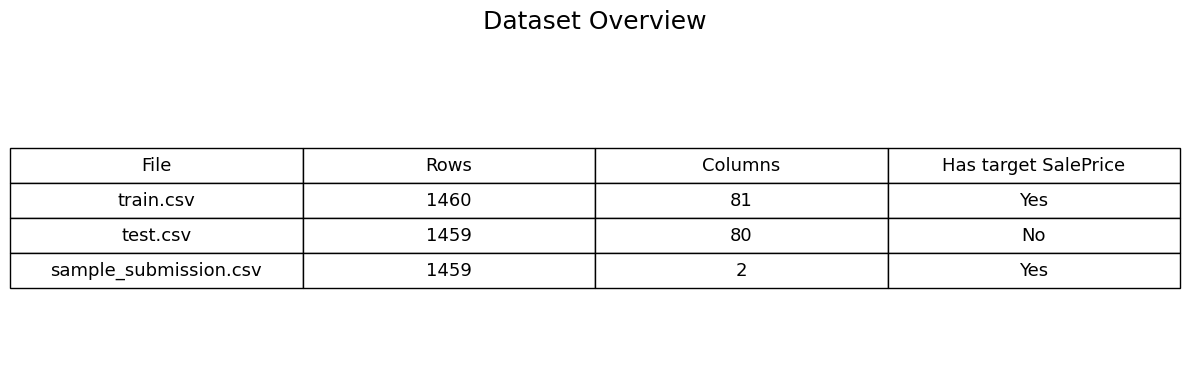

In [4]:
# PRESENTATION FIGURES 01 — Setup + Dataset Overview

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(filename):
    path = os.path.join(FIG_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print("Saved:", path)

print("Figures will be saved to:", FIG_DIR)

overview_df = pd.DataFrame({
    "File": ["train.csv", "test.csv", "sample_submission.csv"],
    "Rows": [train.shape[0], test.shape[0], sample_submission.shape[0]],
    "Columns": [train.shape[1], test.shape[1], sample_submission.shape[1]],
    "Has target SalePrice": [
        "Yes" if "SalePrice" in train.columns else "No",
        "Yes" if "SalePrice" in test.columns else "No",
        "Yes" if "SalePrice" in sample_submission.columns else "No"
    ]
})

display(overview_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

table = ax.table(
    cellText=overview_df.values,
    colLabels=overview_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2)

ax.set_title("Dataset Overview", fontsize=18, pad=20)

save_fig("01_dataset_overview.png")
plt.show()

,Check,Count
0,Train duplicated Id,0
1,Test duplicated Id,0
2,Sample duplicated Id,0
3,Train/Test overlapping Id,0
4,Train duplicated rows,0
5,Test duplicated rows,0
6,Train duplicated features,0
7,Test duplicated features,0


Saved: /kaggle/working/figures/02_data_quality_duplicate_id.png


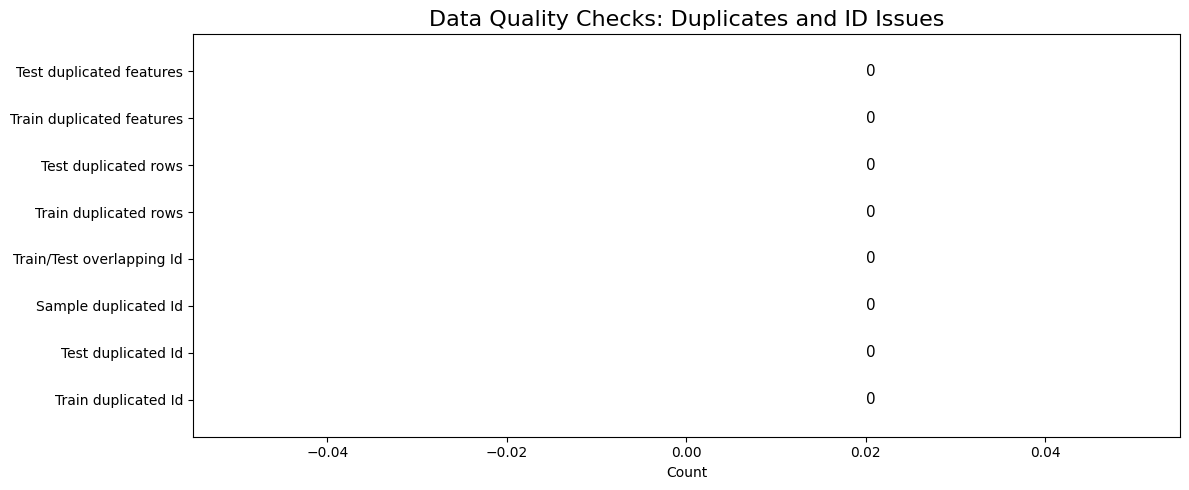

In [5]:
# PRESENTATION FIGURES 02 — Data Quality Checks

quality_checks = []

quality_checks.append(["Train duplicated Id", train["Id"].duplicated().sum()])
quality_checks.append(["Test duplicated Id", test["Id"].duplicated().sum()])
quality_checks.append(["Sample duplicated Id", sample_submission["Id"].duplicated().sum()])

overlap_ids = len(set(train["Id"]).intersection(set(test["Id"])))
quality_checks.append(["Train/Test overlapping Id", overlap_ids])

quality_checks.append(["Train duplicated rows", train.duplicated().sum()])
quality_checks.append(["Test duplicated rows", test.duplicated().sum()])

train_feature_dups = train.drop(columns=["Id", "SalePrice"]).duplicated().sum()
test_feature_dups = test.drop(columns=["Id"]).duplicated().sum()

quality_checks.append(["Train duplicated features", train_feature_dups])
quality_checks.append(["Test duplicated features", test_feature_dups])

quality_df = pd.DataFrame(quality_checks, columns=["Check", "Count"])

display(quality_df)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(quality_df["Check"], quality_df["Count"])
ax.set_xlabel("Count")
ax.set_title("Data Quality Checks: Duplicates and ID Issues", fontsize=16)

for i, v in enumerate(quality_df["Count"]):
    ax.text(v + 0.02, i, str(v), va="center", fontsize=11)

save_fig("02_data_quality_duplicate_id.png")
plt.show()

,Column,Missing Count,Missing Percent
0,PoolQC,1453,99.520548
1,MiscFeature,1406,96.301370
2,Alley,1369,93.767123
3,Fence,1179,80.753425
4,MasVnrType,872,59.726027
5,FireplaceQu,690,47.260274
6,LotFrontage,259,17.739726
7,GarageType,81,5.547945
8,GarageYrBlt,81,5.547945
9,GarageFinish,81,5.547945


Saved: /kaggle/working/figures/03_missing_values_train.png


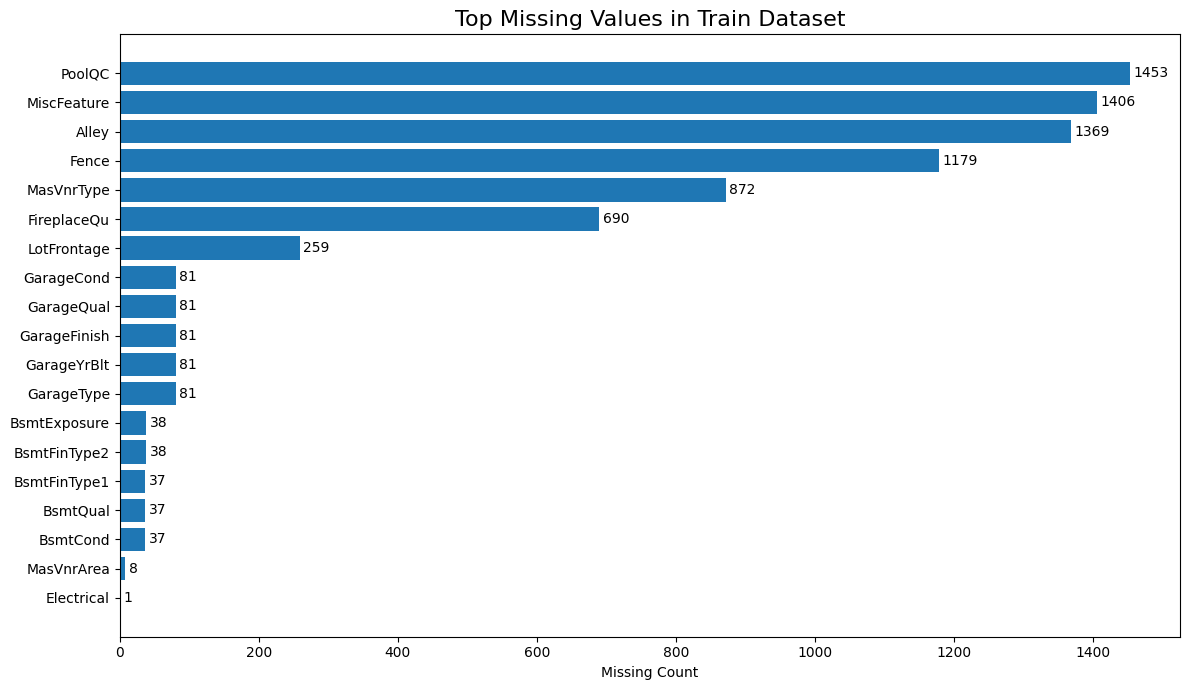

In [6]:
# PRESENTATION FIGURES 03 — Missing Values

missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Column": missing_train.index,
    "Missing Count": missing_train.values,
    "Missing Percent": missing_train.values / len(train) * 100
})

display(missing_df.head(25))

top_missing = missing_df.head(20).sort_values("Missing Count")

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_missing["Column"], top_missing["Missing Count"])
ax.set_xlabel("Missing Count")
ax.set_title("Top Missing Values in Train Dataset", fontsize=16)

for i, v in enumerate(top_missing["Missing Count"]):
    ax.text(v + 5, i, str(v), va="center", fontsize=10)

save_fig("03_missing_values_train.png")
plt.show()

Saved: /kaggle/working/figures/04_saleprice_distribution.png


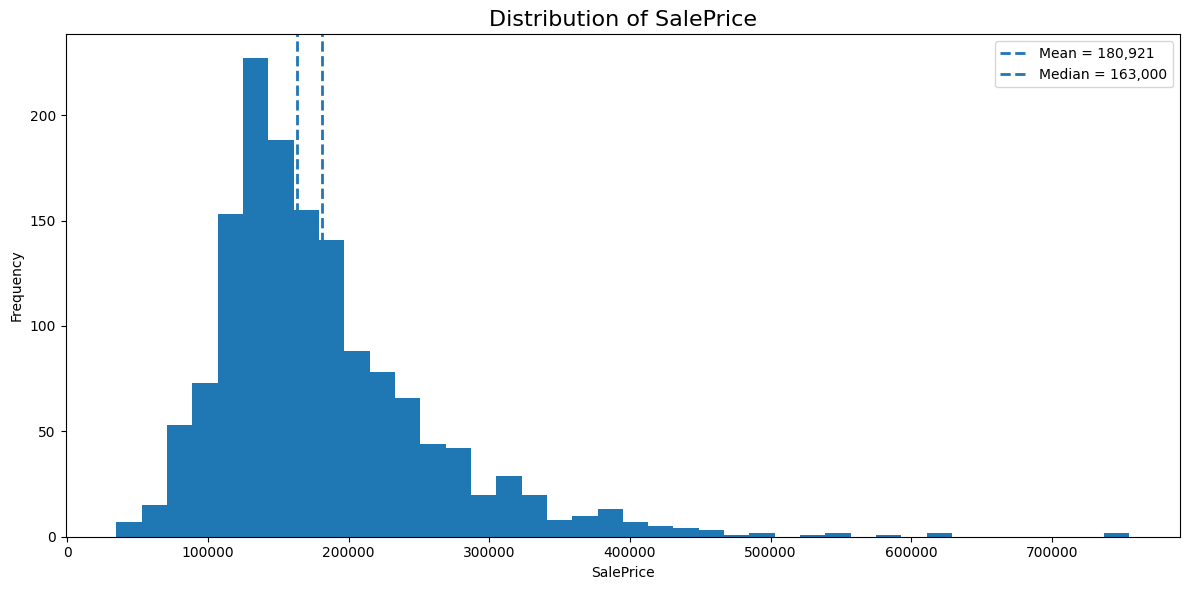

Saved: /kaggle/working/figures/05_log_saleprice_distribution.png


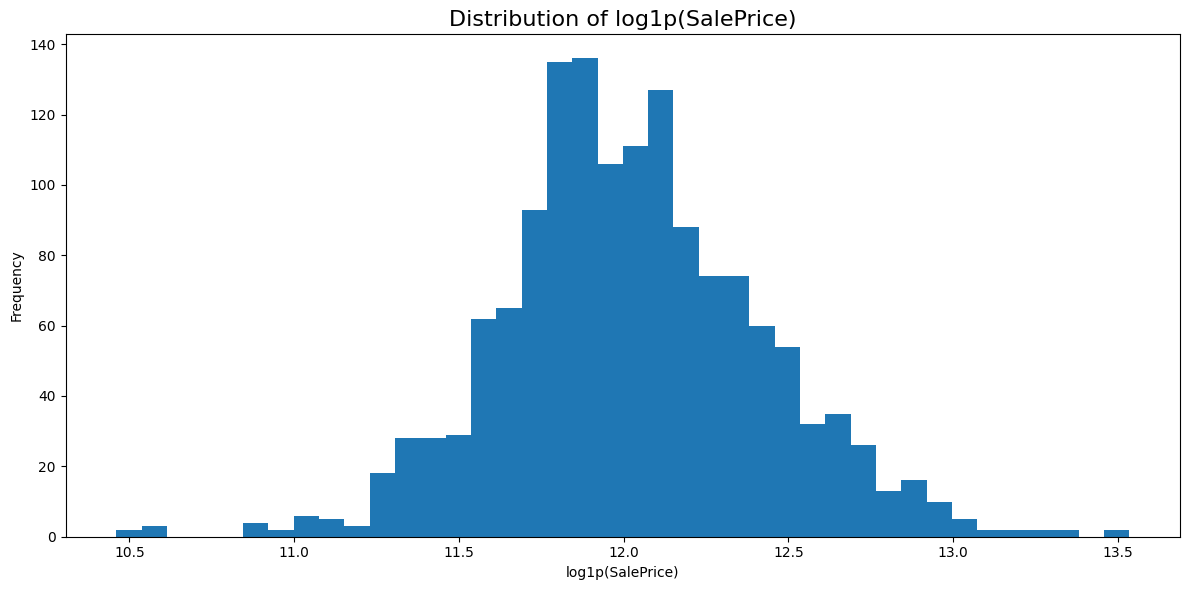

In [7]:
# PRESENTATION FIGURES 04-05 — SalePrice Distribution

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(train["SalePrice"], bins=40)
ax.set_title("Distribution of SalePrice", fontsize=16)
ax.set_xlabel("SalePrice")
ax.set_ylabel("Frequency")

mean_price = train["SalePrice"].mean()
median_price = train["SalePrice"].median()

ax.axvline(mean_price, linestyle="--", linewidth=2, label=f"Mean = {mean_price:,.0f}")
ax.axvline(median_price, linestyle="--", linewidth=2, label=f"Median = {median_price:,.0f}")
ax.legend()

save_fig("04_saleprice_distribution.png")
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(np.log1p(train["SalePrice"]), bins=40)
ax.set_title("Distribution of log1p(SalePrice)", fontsize=16)
ax.set_xlabel("log1p(SalePrice)")
ax.set_ylabel("Frequency")

save_fig("05_log_saleprice_distribution.png")
plt.show()

Saved: /kaggle/working/figures/06_saleprice_by_overallqual_with_trend.png


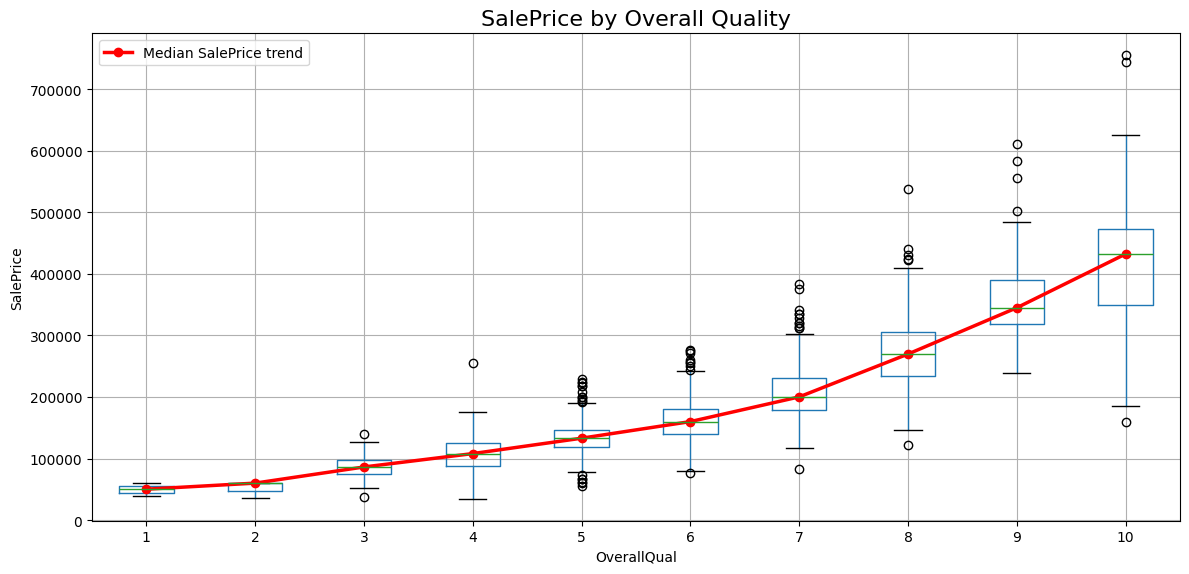

,OverallQual,count,mean,median
0,1,2,50150.000000,50150.0
1,2,3,51770.333333,60000.0
2,3,20,87473.750000,86250.0
3,4,116,108420.655172,108000.0
4,5,397,133523.347607,133000.0
5,6,374,161603.034759,160000.0
6,7,319,207716.423197,200141.0
7,8,168,274735.535714,269750.0
8,9,43,367513.023256,345000.0
9,10,18,438588.388889,432390.0


In [8]:
# PRESENTATION FIGURE 06 — Overall Quality vs SalePrice with Trend Line

fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot
train.boxplot(column="SalePrice", by="OverallQual", ax=ax)

# Tính median SalePrice theo từng mức OverallQual
overallqual_median = train.groupby("OverallQual")["SalePrice"].median()

# Vẽ đường trend màu đỏ theo median
ax.plot(
    overallqual_median.index,
    overallqual_median.values,
    color="red",
    marker="o",
    linewidth=2.5,
    label="Median SalePrice trend"
)

ax.set_title("SalePrice by Overall Quality", fontsize=16)
plt.suptitle("")
ax.set_xlabel("OverallQual")
ax.set_ylabel("SalePrice")
ax.legend()

save_fig("06_saleprice_by_overallqual_with_trend.png")
plt.show()

# Bảng số liệu median/mean để giải thích khi thuyết trình
overallqual_summary = train.groupby("OverallQual")["SalePrice"].agg(
    count="count",
    mean="mean",
    median="median"
).reset_index()

display(overallqual_summary)

In [9]:
#cell7
train_model = train.copy()

outlier_mask = (train_model["GrLivArea"] > 4000) & (train_model["SalePrice"] < 300000)

print("Số outlier bị loại:", outlier_mask.sum())
display(train_model.loc[outlier_mask, ["Id", "GrLivArea", "SalePrice"]])

train_model = train_model.loc[~outlier_mask].reset_index(drop=True)

print("Train shape sau khi loại outlier:", train_model.shape)

Số outlier bị loại: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Train shape sau khi loại outlier: (1458, 81)


Saved: /kaggle/working/figures/07_outlier_grlivarea_saleprice.png


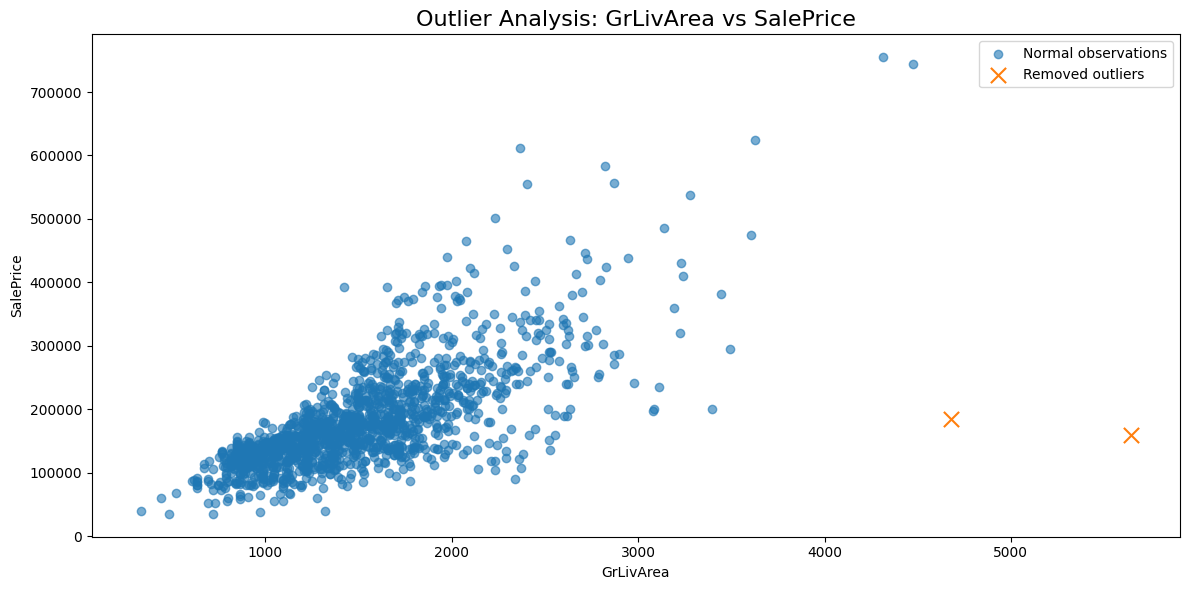

Removed outliers:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [10]:
# PRESENTATION FIGURE 07 — Outlier Analysis

outlier_rule = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    train.loc[~outlier_rule, "GrLivArea"],
    train.loc[~outlier_rule, "SalePrice"],
    alpha=0.6,
    label="Normal observations"
)

ax.scatter(
    train.loc[outlier_rule, "GrLivArea"],
    train.loc[outlier_rule, "SalePrice"],
    s=120,
    marker="x",
    label="Removed outliers"
)

ax.set_title("Outlier Analysis: GrLivArea vs SalePrice", fontsize=16)
ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
ax.legend()

save_fig("07_outlier_grlivarea_saleprice.png")
plt.show()

print("Removed outliers:")
display(train.loc[outlier_rule, ["Id", "GrLivArea", "SalePrice"]])

Saved: /kaggle/working/figures/08_top_numeric_correlations.png


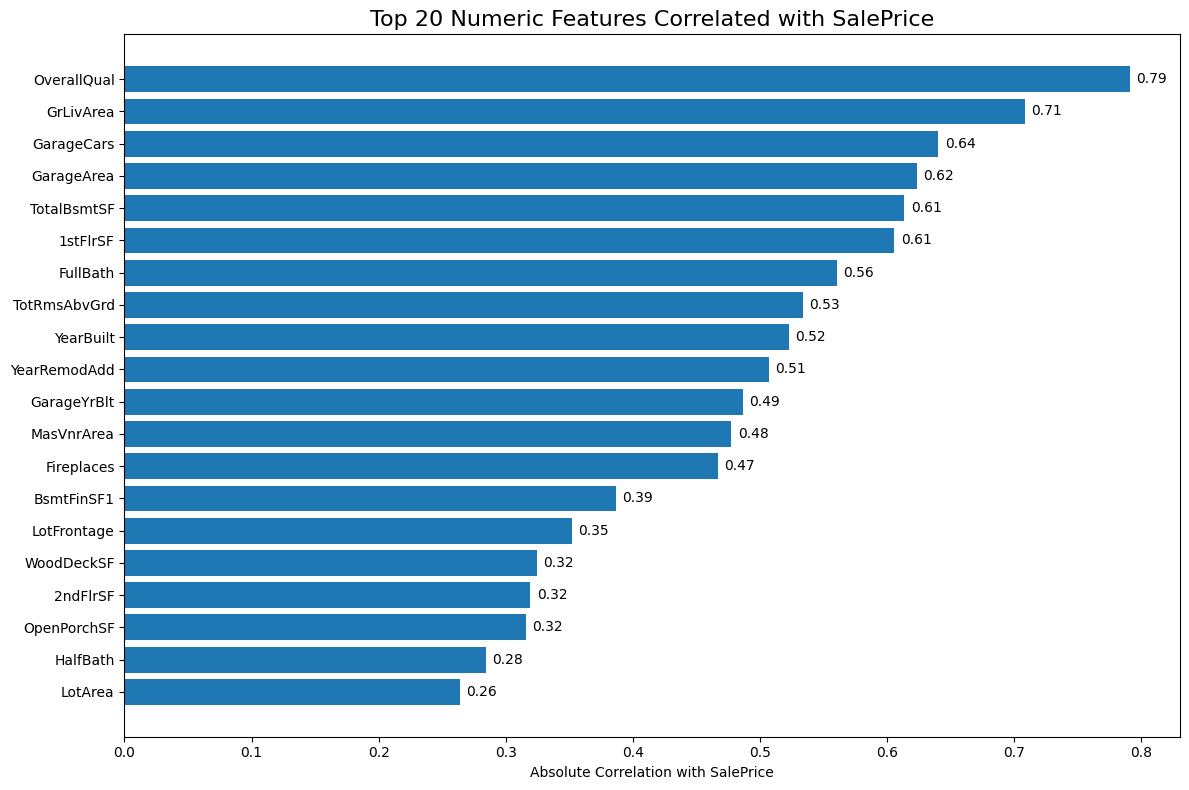

,Feature,Abs Correlation
0,OverallQual,0.790982
1,GrLivArea,0.708624
2,GarageCars,0.640409
3,GarageArea,0.623431
4,TotalBsmtSF,0.613581
5,1stFlrSF,0.605852
6,FullBath,0.560664
7,TotRmsAbvGrd,0.533723
8,YearBuilt,0.522897
9,YearRemodAdd,0.507101


,count,mean,median
Neighborhood,,,
NridgHt,77,316270.623377,315000.0
NoRidge,41,335295.317073,301500.0
StoneBr,25,310499.000000,278000.0
Timber,38,242247.447368,228475.0
Somerst,86,225379.837209,225500.0
Veenker,11,238772.727273,218000.0
Crawfor,51,210624.725490,200624.0
ClearCr,28,212565.428571,200250.0
CollgCr,150,197965.773333,197200.0


Saved: /kaggle/working/figures/09_neighborhood_median_saleprice.png


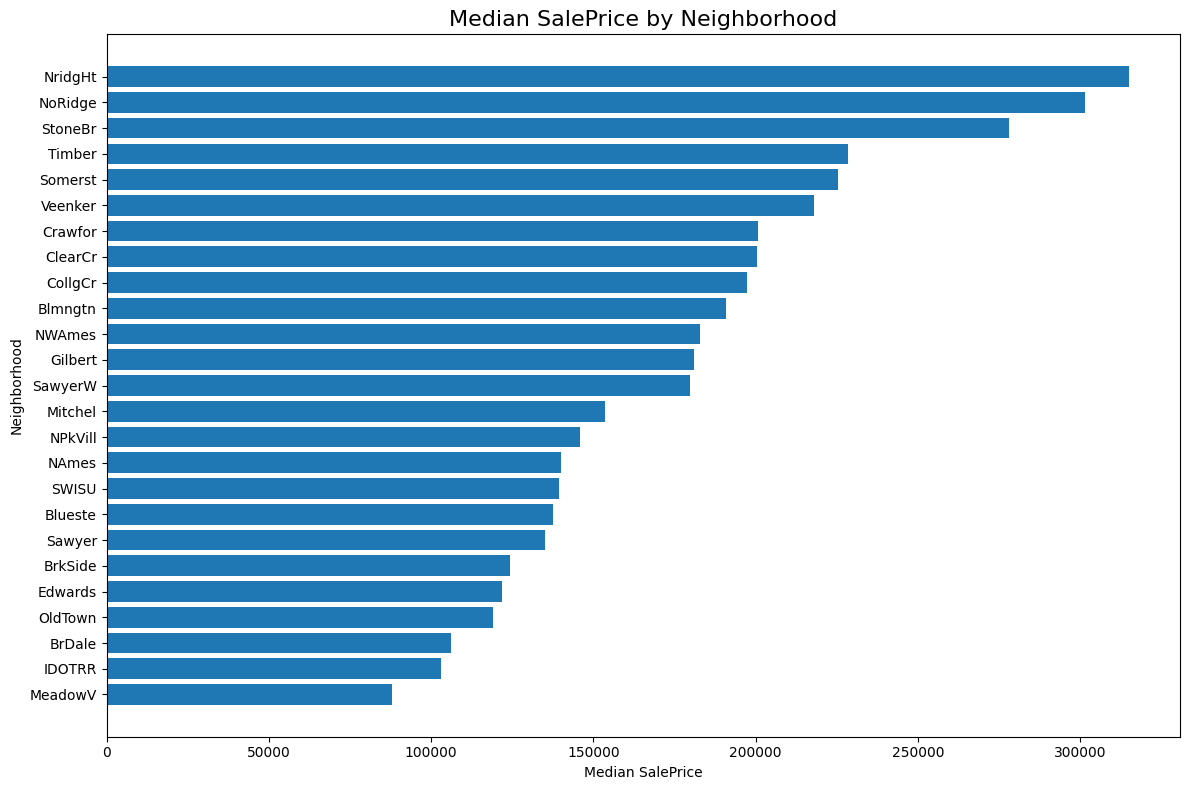

In [11]:
# PRESENTATION FIGURES 08-09 — Correlation and Neighborhood Effect

corr = train.select_dtypes(include=[np.number]).corr(numeric_only=True)["SalePrice"]
corr = corr.drop("SalePrice").abs().sort_values(ascending=False)

top_corr = corr.head(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_corr.index, top_corr.values)
ax.set_title("Top 20 Numeric Features Correlated with SalePrice", fontsize=16)
ax.set_xlabel("Absolute Correlation with SalePrice")

for i, v in enumerate(top_corr.values):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=10)

save_fig("08_top_numeric_correlations.png")
plt.show()

display(corr.head(20).reset_index().rename(columns={"index": "Feature", "SalePrice": "Abs Correlation"}))


neighborhood_price = train.groupby("Neighborhood")["SalePrice"].agg(
    count="count",
    mean="mean",
    median="median"
).sort_values("median", ascending=False)

display(neighborhood_price)

plot_df = neighborhood_price.sort_values("median")

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df.index, plot_df["median"])
ax.set_title("Median SalePrice by Neighborhood", fontsize=16)
ax.set_xlabel("Median SalePrice")
ax.set_ylabel("Neighborhood")

save_fig("09_neighborhood_median_saleprice.png")
plt.show()

In [12]:
#cell8
def add_house_features(df):
    df = df.copy()
    
    if {"GarageYrBlt", "YrSold", "YearBuilt"}.issubset(df.columns):
        invalid_garage_year = df["GarageYrBlt"] > df["YrSold"]
        df.loc[invalid_garage_year, "GarageYrBlt"] = df.loc[invalid_garage_year, "YearBuilt"]
    
    def col(name):
        if name in df.columns:
            return df[name].fillna(0)
        return 0
    
    df["TotalSF"] = col("TotalBsmtSF") + col("1stFlrSF") + col("2ndFlrSF")
    
    df["TotalBath"] = (
        col("FullBath")
        + 0.5 * col("HalfBath")
        + col("BsmtFullBath")
        + 0.5 * col("BsmtHalfBath")
    )
    
    df["TotalPorchSF"] = (
        col("OpenPorchSF")
        + col("EnclosedPorch")
        + col("3SsnPorch")
        + col("ScreenPorch")
        + col("WoodDeckSF")
    )
    
    if {"YrSold", "YearBuilt"}.issubset(df.columns):
        df["HouseAge"] = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
    
    if {"YrSold", "YearRemodAdd"}.issubset(df.columns):
        df["RemodAge"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
        df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    
    if {"YrSold", "GarageYrBlt"}.issubset(df.columns):
        df["GarageAge"] = (df["YrSold"] - df["GarageYrBlt"]).clip(lower=0)
        df["GarageAge"] = df["GarageAge"].fillna(0)
    
    df["HasGarage"] = (col("GarageArea") > 0).astype(int)
    df["HasBasement"] = (col("TotalBsmtSF") > 0).astype(int)
    df["HasPool"] = (col("PoolArea") > 0).astype(int)
    df["HasFireplace"] = (col("Fireplaces") > 0).astype(int)
    df["Has2ndFloor"] = (col("2ndFlrSF") > 0).astype(int)
    
    if "OverallQual" in df.columns:
        df["OverallQual_TotalSF"] = df["OverallQual"] * df["TotalSF"]
        df["OverallQual_GrLivArea"] = df["OverallQual"] * col("GrLivArea")
    
    if "OverallCond" in df.columns:
        df["OverallCond_TotalSF"] = df["OverallCond"] * df["TotalSF"]
    
    if "SaleType" in df.columns:
        df["IsNewHouse"] = (df["SaleType"] == "New").astype(int)
    
    return df

In [13]:
#cell9
def preprocess_all_data(all_data, use_feature_engineering=True):
    df = all_data.copy()
    
    if use_feature_engineering:
        df = add_house_features(df)
    
    if "Id" in df.columns:
        df = df.drop(columns=["Id"])
    
    for c in ["MSSubClass", "MoSold", "YrSold"]:
        if c in df.columns:
            df[c] = df[c].astype(str)
    
    none_cols = [
        "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
        "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "PoolQC", "Fence", "MiscFeature", "MasVnrType"
    ]
    
    for c in none_cols:
        if c in df.columns:
            df[c] = df[c].fillna("None")
    
    if "LotFrontage" in df.columns:
        if "Neighborhood" in df.columns:
            df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
                lambda s: s.fillna(s.median())
            )
        df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
    
    zero_cols = [
        "GarageYrBlt", "GarageArea", "GarageCars",
        "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
        "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"
    ]
    
    for c in zero_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)
    
    quality_map = {
        "None": 0,
        "Po": 1,
        "Fa": 2,
        "TA": 3,
        "Gd": 4,
        "Ex": 5
    }
    
    quality_cols = [
        "ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
        "HeatingQC", "KitchenQual", "FireplaceQu",
        "GarageQual", "GarageCond", "PoolQC"
    ]
    
    for c in quality_cols:
        if c in df.columns:
            df[c] = df[c].map(quality_map).fillna(0).astype(int)
    
    exposure_map = {
        "None": 0,
        "No": 1,
        "Mn": 2,
        "Av": 3,
        "Gd": 4
    }
    
    if "BsmtExposure" in df.columns:
        df["BsmtExposure"] = df["BsmtExposure"].map(exposure_map).fillna(0).astype(int)
    
    fin_type_map = {
        "None": 0,
        "Unf": 1,
        "LwQ": 2,
        "Rec": 3,
        "BLQ": 4,
        "ALQ": 5,
        "GLQ": 6
    }
    
    for c in ["BsmtFinType1", "BsmtFinType2"]:
        if c in df.columns:
            df[c] = df[c].map(fin_type_map).fillna(0).astype(int)
    
    garage_finish_map = {
        "None": 0,
        "Unf": 1,
        "RFn": 2,
        "Fin": 3
    }
    
    if "GarageFinish" in df.columns:
        df["GarageFinish"] = df["GarageFinish"].map(garage_finish_map).fillna(0).astype(int)
    
    functional_map = {
        "Sal": 0,
        "Sev": 1,
        "Maj2": 2,
        "Maj1": 3,
        "Mod": 4,
        "Min2": 5,
        "Min1": 6,
        "Typ": 7
    }
    
    if "Functional" in df.columns:
        df["Functional"] = df["Functional"].map(functional_map).fillna(7).astype(int)
    
    fence_map = {
        "None": 0,
        "MnWw": 1,
        "GdWo": 2,
        "MnPrv": 3,
        "GdPrv": 4
    }
    
    if "Fence" in df.columns:
        df["Fence"] = df["Fence"].map(fence_map).fillna(0).astype(int)
    
    paved_drive_map = {
        "N": 0,
        "P": 1,
        "Y": 2
    }
    
    if "PavedDrive" in df.columns:
        df["PavedDrive"] = df["PavedDrive"].map(paved_drive_map).fillna(0).astype(int)
    
    central_air_map = {
        "N": 0,
        "Y": 1
    }
    
    if "CentralAir" in df.columns:
        df["CentralAir"] = df["CentralAir"].map(central_air_map).fillna(0).astype(int)
    
    lot_shape_map = {
        "IR3": 0,
        "IR2": 1,
        "IR1": 2,
        "Reg": 3
    }
    
    if "LotShape" in df.columns:
        df["LotShape"] = df["LotShape"].map(lot_shape_map).fillna(0).astype(int)
    
    land_slope_map = {
        "Sev": 1,
        "Mod": 2,
        "Gtl": 3
    }
    
    if "LandSlope" in df.columns:
        df["LandSlope"] = df["LandSlope"].map(land_slope_map).fillna(0).astype(int)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    for c in numeric_cols:
        df[c] = df[c].fillna(df[c].median())
    
    for c in categorical_cols:
        if df[c].mode().empty:
            df[c] = df[c].fillna("Missing")
        else:
            df[c] = df[c].fillna(df[c].mode()[0])
    
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)
    
    return df_encoded

In [14]:

# Cell 10 — Chuẩn bị train/test matrix và chia train/validation

# Kiểm tra các hàm cần thiết đã tồn tại chưa
if "preprocess_all_data" not in globals():
    raise NameError("Bạn chưa chạy Cell 8: hàm preprocess_all_data chưa được định nghĩa.")

# Nếu chưa có train_model thì tạo lại từ train
if "train_model" not in globals():
    train_model = train.copy()

    # Loại outlier rõ ràng
    outlier_mask = (train_model["GrLivArea"] > 4000) & (train_model["SalePrice"] < 300000)
    print("Số outlier bị loại:", outlier_mask.sum())

    train_model = train_model.loc[~outlier_mask].reset_index(drop=True)

# Tạo biến mục tiêu y
y = np.log1p(train_model["SalePrice"])

# Lưu Id của test để tạo submission
test_ids = test["Id"].copy()

# Gộp train và test để xử lý đồng nhất
all_data = pd.concat(
    [
        train_model.drop(columns=["SalePrice"]),
        test
    ],
    axis=0,
    ignore_index=True
)

# Tiền xử lý + feature engineering
processed = preprocess_all_data(all_data, use_feature_engineering=True)

# Tách lại X train và X test
X = processed.iloc[:len(train_model), :].copy()
X_test_final = processed.iloc[len(train_model):, :].copy()

print("X shape:", X.shape)
print("X_test_final shape:", X_test_final.shape)
print("y shape:", y.shape)

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in X_test_final:", X_test_final.isnull().sum().sum())

assert X.isnull().sum().sum() == 0
assert X_test_final.isnull().sum().sum() == 0
assert len(X) == len(y)
assert len(X_test_final) == len(test_ids)

# Chia train/validation 80/20
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X shape: (1458, 270)
X_test_final shape: (1459, 270)
y shape: (1458,)
Missing values in X: 0
Missing values in X_test_final: 0
X_train: (1166, 270)
X_valid: (292, 270)
y_train: (1166,)
y_valid: (292,)


Saved: /kaggle/working/figures/10_modeling_pipeline.png


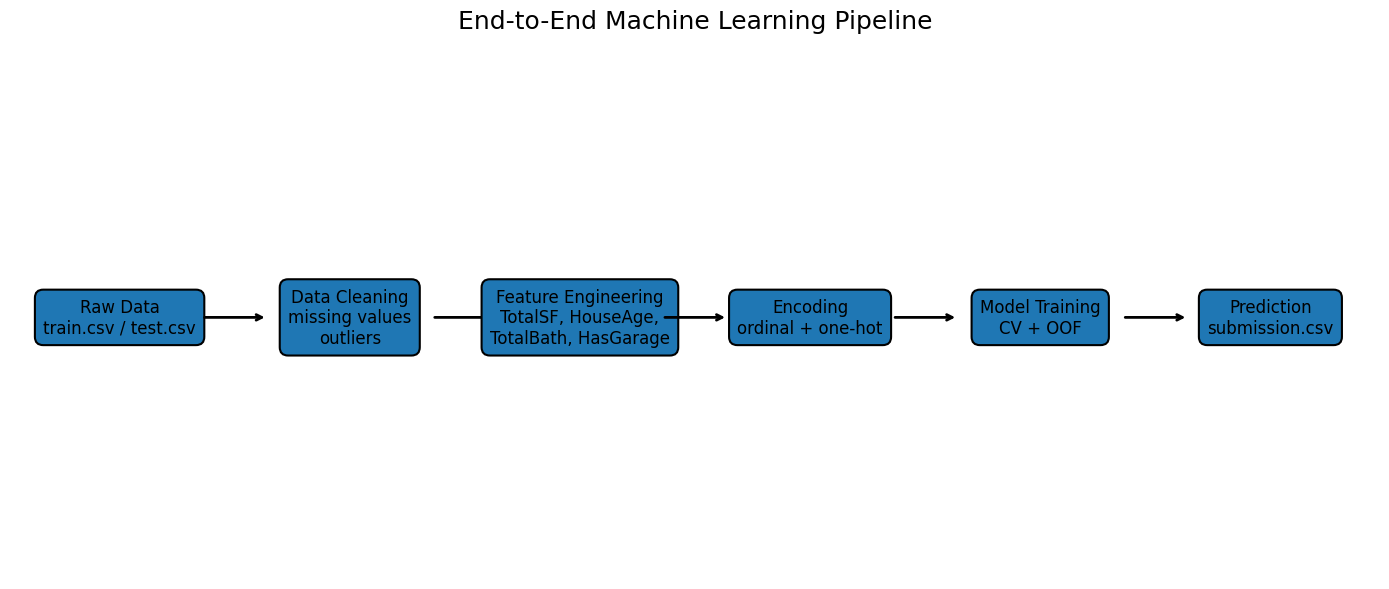

,Object,Count
0,Original train columns,81
1,Original test columns,80
2,Processed X columns,270
3,Processed X_test columns,270


Saved: /kaggle/working/figures/11_feature_matrix_summary.png


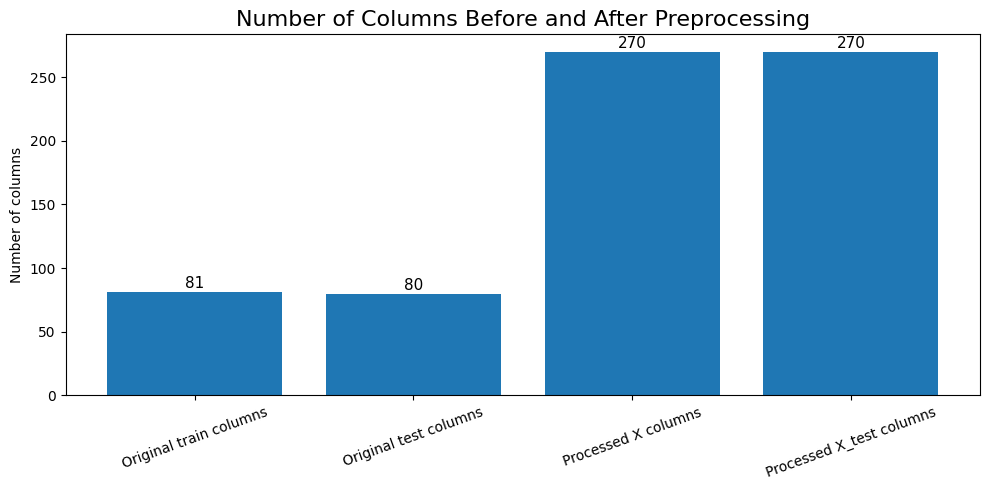

In [15]:
# PRESENTATION FIGURES 10-11 — Pipeline and Feature Matrix Summary

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis("off")

steps = [
    "Raw Data\ntrain.csv / test.csv",
    "Data Cleaning\nmissing values\noutliers",
    "Feature Engineering\nTotalSF, HouseAge,\nTotalBath, HasGarage",
    "Encoding\nordinal + one-hot",
    "Model Training\nCV + OOF",
    "Prediction\nsubmission.csv"
]

x_positions = np.linspace(0.08, 0.92, len(steps))
y_pos = 0.5

for i, (x, step) in enumerate(zip(x_positions, steps)):
    ax.text(
        x, y_pos, step,
        ha="center", va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", linewidth=1.5)
    )
    
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i+1] - 0.06, y_pos),
            xytext=(x + 0.06, y_pos),
            arrowprops=dict(arrowstyle="->", linewidth=2)
        )

ax.set_title("End-to-End Machine Learning Pipeline", fontsize=18, pad=20)

save_fig("10_modeling_pipeline.png")
plt.show()


feature_summary = pd.DataFrame({
    "Object": ["Original train columns", "Original test columns", "Processed X columns", "Processed X_test columns"],
    "Count": [train.shape[1], test.shape[1], X.shape[1], X_test_final.shape[1]]
})

display(feature_summary)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(feature_summary["Object"], feature_summary["Count"])
ax.set_title("Number of Columns Before and After Preprocessing", fontsize=16)
ax.set_ylabel("Number of columns")
ax.tick_params(axis="x", rotation=20)

for i, v in enumerate(feature_summary["Count"]):
    ax.text(i, v + 3, str(v), ha="center", fontsize=11)

save_fig("11_feature_matrix_summary.png")
plt.show()

In [16]:
# Cell 11 — Xử lý skew cho numeric features

from scipy.stats import skew

X_opt = X.copy()
X_test_opt = X_test_final.copy()

skewed_features = []

for col in X_opt.columns:
    # Chỉ xử lý cột numeric liên tục, bỏ qua dummy 0/1
    if X_opt[col].dtype != "object":
        if X_opt[col].nunique() > 20 and X_opt[col].min() >= 0:
            sk = skew(X_opt[col])
            if sk > 0.75:
                skewed_features.append(col)

print("Số feature bị skew được log1p:", len(skewed_features))
print(skewed_features[:30])

for col in skewed_features:
    X_opt[col] = np.log1p(X_opt[col])
    X_test_opt[col] = np.log1p(X_test_opt[col])

X = X_opt
X_test_final = X_test_opt

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X after skew transform:", X.shape)
print("X_test_final after skew transform:", X_test_final.shape)

Số feature bị skew được log1p: 20
['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'MiscVal', 'TotalSF', 'TotalPorchSF', 'OverallQual_TotalSF', 'OverallQual_GrLivArea', 'OverallCond_TotalSF']
X after skew transform: (1458, 270)
X_test_final after skew transform: (1459, 270)


In [17]:
# Cell 13 — Khai báo nhiều mô hình hơn

from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

models = {}

models["Ridge"] = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10.0, random_state=RANDOM_STATE))
])

models["Lasso"] = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=50000, random_state=RANDOM_STATE))
])

models["ElasticNet"] = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(
        alpha=0.0007,
        l1_ratio=0.9,
        max_iter=50000,
        random_state=RANDOM_STATE
    ))
])

models["BayesianRidge"] = Pipeline([
    ("scaler", RobustScaler()),
    ("model", BayesianRidge())
])

models["KernelRidge"] = Pipeline([
    ("scaler", RobustScaler()),
    ("model", KernelRidge(
        alpha=0.6,
        kernel="polynomial",
        degree=2,
        coef0=2.5
    ))
])

models["RandomForest"] = RandomForestRegressor(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models["ExtraTrees"] = ExtraTreesRegressor(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models["GradientBoosting"] = GradientBoostingRegressor(
    n_estimators=1800,
    learning_rate=0.025,
    max_depth=3,
    min_samples_leaf=3,
    min_samples_split=8,
    subsample=0.8,
    max_features="sqrt",
    loss="huber",
    random_state=RANDOM_STATE
)

models["HistGradientBoosting"] = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.025,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=RANDOM_STATE
)

# XGBoost
try:
    from xgboost import XGBRegressor
    
    models["XGBoost"] = XGBRegressor(
        n_estimators=1800,
        learning_rate=0.025,
        max_depth=3,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0005,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=2
    )
    print("Added XGBoost.")
except Exception as e:
    print("Skip XGBoost:", e)

# LightGBM
try:
    from lightgbm import LGBMRegressor
    
    models["LightGBM"] = LGBMRegressor(
        n_estimators=2500,
        learning_rate=0.015,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0005,
        reg_lambda=0.5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    print("Added LightGBM.")
except Exception as e:
    print("Skip LightGBM:", e)

# CatBoost
try:
    from catboost import CatBoostRegressor
    
    models["CatBoost"] = CatBoostRegressor(
        iterations=2500,
        learning_rate=0.02,
        depth=4,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False
    )
    print("Added CatBoost.")
except Exception as e:
    print("Skip CatBoost:", e)

print("Total models:", len(models))
print(list(models.keys()))

Added XGBoost.
Added LightGBM.
Added CatBoost.
Total models: 12
['Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'KernelRidge', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [18]:
# Cell 15A — Khởi tạo Cross-validation setup

import time
import os

cv_results_path = "/kaggle/working/cv_results_partial.csv"

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

# Nếu đã có file kết quả cũ thì đọc lại để không mất kết quả
if os.path.exists(cv_results_path):
    cv_results_df_old = pd.read_csv(cv_results_path)
    cv_results = cv_results_df_old.to_dict("records")
    print("Đã đọc kết quả CV cũ:")
    display(cv_results_df_old)
else:
    print("Bắt đầu CV mới. Chưa có kết quả cũ.")

print("Available models:")
print(list(models.keys()))

Bắt đầu CV mới. Chưa có kết quả cũ.
Available models:
['Ridge', 'Lasso', 'ElasticNet', 'BayesianRidge', 'KernelRidge', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [19]:
# Cell 15B — Hàm chạy CV cho từng model

def run_cv_one_model(model_name, overwrite=False):
    global cv_results
    
    if model_name not in models:
        raise ValueError(f"Model '{model_name}' không tồn tại trong models.")
    
    # Nếu model đã chạy rồi thì bỏ qua, trừ khi overwrite=True
    existing_names = [row["model"] for row in cv_results]
    if (model_name in existing_names) and (not overwrite):
        print(f"{model_name} đã có kết quả CV. Bỏ qua.")
        return
    
    # Nếu overwrite=True thì xóa kết quả cũ của model đó
    if overwrite:
        cv_results = [row for row in cv_results if row["model"] != model_name]
    
    print(f"\nCross-validating {model_name}...")
    start_time = time.time()
    
    scores = cross_val_score(
        clone(models[model_name]),
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=kf,
        n_jobs=1
    )
    
    rmse_scores = np.sqrt(-scores)
    elapsed = time.time() - start_time
    
    result = {
        "model": model_name,
        "cv_rmse_mean": rmse_scores.mean(),
        "cv_rmse_std": rmse_scores.std(),
        "time_seconds": elapsed,
        "fold_1": rmse_scores[0],
        "fold_2": rmse_scores[1],
        "fold_3": rmse_scores[2],
        "fold_4": rmse_scores[3],
        "fold_5": rmse_scores[4]
    }
    
    cv_results.append(result)
    
    cv_results_df_temp = pd.DataFrame(cv_results).sort_values("cv_rmse_mean")
    cv_results_df_temp.to_csv(cv_results_path, index=False)
    
    print(f"{model_name}: mean={rmse_scores.mean():.5f}, std={rmse_scores.std():.5f}, time={elapsed:.1f}s")
    print("Fold scores:", rmse_scores)
    print(f"Đã lưu tạm vào: {cv_results_path}")
    
    display(cv_results_df_temp)

In [20]:
run_cv_one_model("Ridge")


Cross-validating Ridge...
Ridge: mean=0.11336, std=0.00841, time=0.7s
Fold scores: [0.11469675 0.11321824 0.11951765 0.12165769 0.09771556]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716


In [21]:
run_cv_one_model("Lasso")


Cross-validating Lasso...
Lasso: mean=0.11131, std=0.00721, time=0.9s
Fold scores: [0.10954087 0.1123275  0.1200165  0.11594227 0.09873126]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716


In [22]:
run_cv_one_model("ElasticNet")


Cross-validating ElasticNet...
ElasticNet: mean=0.11153, std=0.00723, time=0.9s
Fold scores: [0.11003163 0.1120529  0.12075797 0.11575792 0.09905399]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716


In [23]:
run_cv_one_model("BayesianRidge")


Cross-validating BayesianRidge...
BayesianRidge: mean=0.11332, std=0.00841, time=0.9s
Fold scores: [0.11486931 0.11280449 0.11971264 0.12148331 0.09771757]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716


In [24]:
run_cv_one_model("KernelRidge")


Cross-validating KernelRidge...
KernelRidge: mean=0.11509, std=0.00645, time=1.3s
Fold scores: [0.11556931 0.11378009 0.12008871 0.12230956 0.10372608]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726


In [25]:
run_cv_one_model("RandomForest")


Cross-validating RandomForest...
RandomForest: mean=0.12728, std=0.00878, time=9.5s
Fold scores: [0.13535712 0.12163039 0.13058324 0.13585574 0.1129943 ]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994


In [26]:
run_cv_one_model("ExtraTrees")


Cross-validating ExtraTrees...
ExtraTrees: mean=0.13156, std=0.00928, time=8.2s
Fold scores: [0.14090456 0.12771488 0.12838647 0.14295654 0.11781317]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994
6,ExtraTrees,0.131555,0.009285,8.152227,0.140905,0.127715,0.128386,0.142957,0.117813


In [27]:
run_cv_one_model("GradientBoosting")


Cross-validating GradientBoosting...
GradientBoosting: mean=0.10796, std=0.00711, time=40.8s
Fold scores: [0.10970978 0.10509681 0.11145969 0.11740873 0.09611791]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
7,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994
6,ExtraTrees,0.131555,0.009285,8.152227,0.140905,0.127715,0.128386,0.142957,0.117813


In [28]:
run_cv_one_model("HistGradientBoosting")


Cross-validating HistGradientBoosting...
HistGradientBoosting: mean=0.12139, std=0.00709, time=49.6s
Fold scores: [0.1245013  0.1178787  0.1268494  0.12853945 0.10919565]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
7,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
8,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994
6,ExtraTrees,0.131555,0.009285,8.152227,0.140905,0.127715,0.128386,0.142957,0.117813


In [29]:
if "XGBoost" in models:
    run_cv_one_model("XGBoost")
else:
    print("XGBoost không có trong models.")


Cross-validating XGBoost...
XGBoost: mean=0.11189, std=0.00690, time=13.7s
Fold scores: [0.11359685 0.10861345 0.11656497 0.12028022 0.10038324]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
7,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
9,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
8,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994
6,ExtraTrees,0.131555,0.009285,8.152227,0.140905,0.127715,0.128386,0.142957,0.117813


In [30]:
if "LightGBM" in models:
    run_cv_one_model("LightGBM")
else:
    print("LightGBM không có trong models.")


Cross-validating LightGBM...
LightGBM: mean=0.12015, std=0.00717, time=32.1s
Fold scores: [0.12352927 0.11622409 0.12649148 0.12657474 0.1079443 ]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
7,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
9,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
10,LightGBM,0.120153,0.007174,32.057665,0.123529,0.116224,0.126491,0.126575,0.107944
8,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196
5,RandomForest,0.127284,0.008783,9.548529,0.135357,0.121630,0.130583,0.135856,0.112994


In [31]:
if "CatBoost" in models:
    run_cv_one_model("CatBoost")
else:
    print("CatBoost không có trong models.")


Cross-validating CatBoost...
CatBoost: mean=0.11115, std=0.00792, time=29.4s
Fold scores: [0.1094965  0.10665883 0.11769766 0.1220713  0.09981365]
Đã lưu tạm vào: /kaggle/working/cv_results_partial.csv


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
7,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
11,CatBoost,0.111148,0.007919,29.437330,0.109496,0.106659,0.117698,0.122071,0.099814
1,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
2,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
9,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
3,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
0,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
4,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
10,LightGBM,0.120153,0.007174,32.057665,0.123529,0.116224,0.126491,0.126575,0.107944
8,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196


In [32]:
# Cell 15Z — Tổng hợp kết quả CV cuối cùng

cv_results_df = pd.read_csv(cv_results_path)
cv_results_df = cv_results_df.sort_values("cv_rmse_mean").reset_index(drop=True)

display(cv_results_df)

cv_results_df.to_csv("/kaggle/working/cv_results.csv", index=False)

print("Đã lưu kết quả cuối cùng:")
print("/kaggle/working/cv_results.csv")

print("\nTop models:")
display(cv_results_df.head(6))

,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
0,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,CatBoost,0.111148,0.007919,29.437330,0.109496,0.106659,0.117698,0.122071,0.099814
2,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
3,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
4,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
5,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
6,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
7,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
8,LightGBM,0.120153,0.007174,32.057665,0.123529,0.116224,0.126491,0.126575,0.107944
9,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196


Đã lưu kết quả cuối cùng:
/kaggle/working/cv_results.csv

Top models:


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
0,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,CatBoost,0.111148,0.007919,29.437330,0.109496,0.106659,0.117698,0.122071,0.099814
2,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
3,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
4,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
5,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718


,model,cv_rmse_mean,cv_rmse_std,time_seconds,fold_1,fold_2,fold_3,fold_4,fold_5
0,GradientBoosting,0.107959,0.007114,40.752156,0.109710,0.105097,0.111460,0.117409,0.096118
1,CatBoost,0.111148,0.007919,29.437330,0.109496,0.106659,0.117698,0.122071,0.099814
2,Lasso,0.111312,0.007206,0.912746,0.109541,0.112327,0.120017,0.115942,0.098731
3,ElasticNet,0.111531,0.007228,0.891845,0.110032,0.112053,0.120758,0.115758,0.099054
4,XGBoost,0.111888,0.006904,13.748828,0.113597,0.108613,0.116565,0.120280,0.100383
5,BayesianRidge,0.113317,0.008410,0.904853,0.114869,0.112804,0.119713,0.121483,0.097718
6,Ridge,0.113361,0.008406,0.734487,0.114697,0.113218,0.119518,0.121658,0.097716
7,KernelRidge,0.115095,0.006453,1.330229,0.115569,0.113780,0.120089,0.122310,0.103726
8,LightGBM,0.120153,0.007174,32.057665,0.123529,0.116224,0.126491,0.126575,0.107944
9,HistGradientBoosting,0.121393,0.007094,49.603933,0.124501,0.117879,0.126849,0.128539,0.109196


Saved: /kaggle/working/figures/12_model_comparison_cv_rmse.png


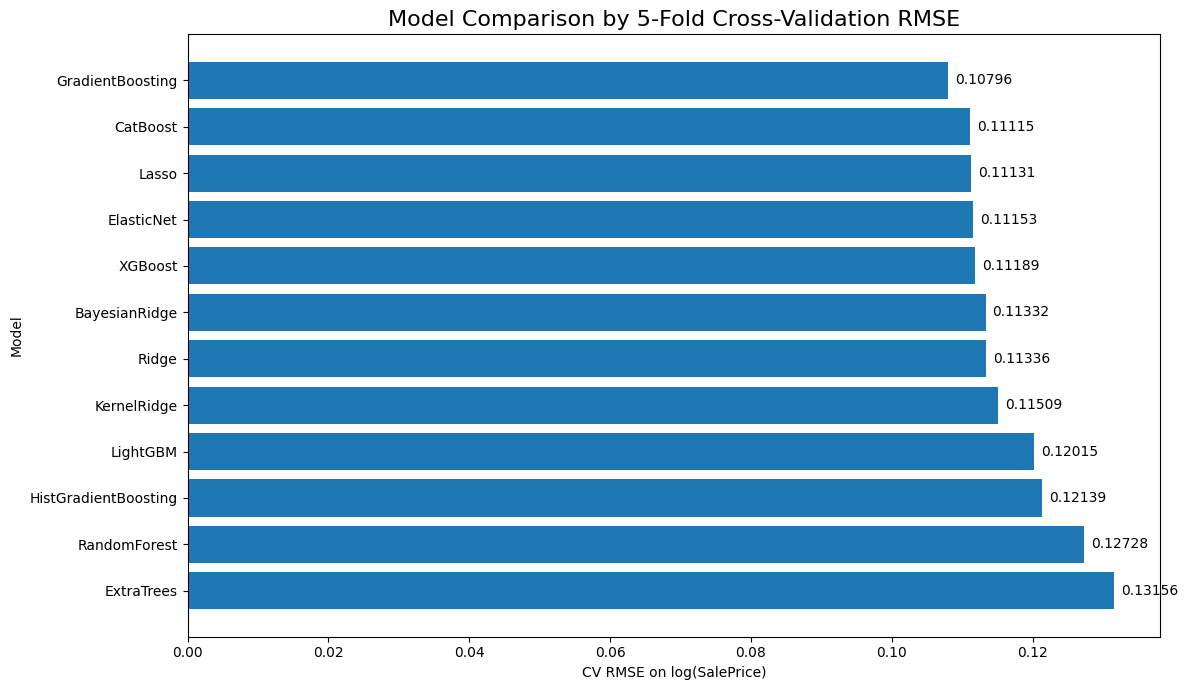

,model,time_seconds,cv_rmse_mean
6,Ridge,0.734487,0.113361
3,ElasticNet,0.891845,0.111531
5,BayesianRidge,0.904853,0.113317
2,Lasso,0.912746,0.111312
7,KernelRidge,1.330229,0.115095
11,ExtraTrees,8.152227,0.131555
10,RandomForest,9.548529,0.127284
4,XGBoost,13.748828,0.111888
1,CatBoost,29.437330,0.111148
8,LightGBM,32.057665,0.120153


Saved: /kaggle/working/figures/13_model_runtime_comparison.png


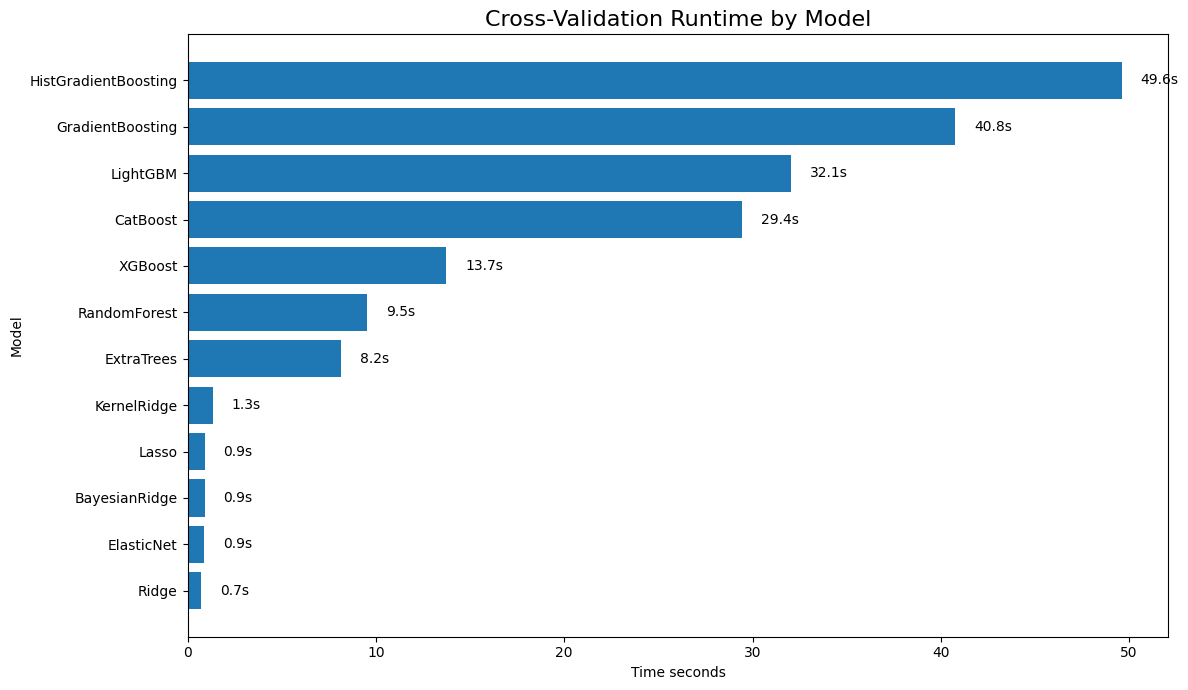

In [33]:
# PRESENTATION FIGURE 12 — Model Comparison

model_compare = cv_results_df.copy()
model_compare = model_compare.sort_values("cv_rmse_mean").reset_index(drop=True)

display(model_compare)

plot_df = model_compare.sort_values("cv_rmse_mean", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(plot_df["model"], plot_df["cv_rmse_mean"])
ax.set_title("Model Comparison by 5-Fold Cross-Validation RMSE", fontsize=16)
ax.set_xlabel("CV RMSE on log(SalePrice)")
ax.set_ylabel("Model")
ax.invert_yaxis()

for i, v in enumerate(plot_df["cv_rmse_mean"]):
    ax.text(v + 0.001, i, f"{v:.5f}", va="center", fontsize=10)

save_fig("12_model_comparison_cv_rmse.png")
plt.show()


if "time_seconds" in cv_results_df.columns:
    runtime_df = cv_results_df.sort_values("time_seconds", ascending=True)
    
    display(runtime_df[["model", "time_seconds", "cv_rmse_mean"]])
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(runtime_df["model"], runtime_df["time_seconds"])
    ax.set_title("Cross-Validation Runtime by Model", fontsize=16)
    ax.set_xlabel("Time seconds")
    ax.set_ylabel("Model")
    
    for i, v in enumerate(runtime_df["time_seconds"]):
        ax.text(v + 1, i, f"{v:.1f}s", va="center", fontsize=10)
    
    save_fig("13_model_runtime_comparison.png")
    plt.show()
else:
    print("cv_results_df does not have time_seconds column.")

In [34]:
# Cell 16 — OOF Weighted Blending để tạo submission tốt hơn

from scipy.optimize import minimize

def rmse_log(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

# Chọn top model theo CV
top_k = min(6, len(cv_results_df))
selected_model_names = cv_results_df.head(top_k)["model"].tolist()

print("Selected models for OOF blending:")
print(selected_model_names)

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_preds = pd.DataFrame(index=X.index)
test_preds = pd.DataFrame(index=X_test_final.index)

for name in selected_model_names:
    print(f"\nOOF training model: {name}")
    
    oof = np.zeros(len(X))
    test_fold_preds = []
    
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):
        X_tr = X.iloc[train_idx]
        X_val = X.iloc[valid_idx]
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[valid_idx]
        
        model = clone(models[name])
        model.fit(X_tr, y_tr)
        
        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test_final)
        
        oof[valid_idx] = val_pred
        test_fold_preds.append(test_pred)
        
        fold_rmse = rmse_log(y_val, val_pred)
        print(f"  Fold {fold}: RMSE = {fold_rmse:.5f}")
    
    model_oof_rmse = rmse_log(y, oof)
    print(f"{name} OOF RMSE: {model_oof_rmse:.5f}")
    
    oof_preds[name] = oof
    test_preds[name] = np.mean(test_fold_preds, axis=0)

display(oof_preds.head())
display(test_preds.head())

# Tối ưu trọng số blend
oof_matrix = oof_preds.values
test_matrix = test_preds.values
y_array = y.values

def blend_objective(weights):
    blended = oof_matrix @ weights
    return rmse_log(y_array, blended)

n_models = len(selected_model_names)
initial_weights = np.ones(n_models) / n_models

bounds = [(0, 1)] * n_models
constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}

result = minimize(
    blend_objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

best_weights = result.x
blend_oof_pred = oof_matrix @ best_weights
blend_oof_rmse = rmse_log(y_array, blend_oof_pred)

print("\nOptimized blend weights:")
for name, weight in zip(selected_model_names, best_weights):
    print(f"{name}: {weight:.4f}")

print("\nOOF Blend RMSE:", blend_oof_rmse)

# Dự đoán test bằng weighted blend
blend_test_log = test_matrix @ best_weights
blend_test_price = np.expm1(blend_test_log)
blend_test_price = np.maximum(blend_test_price, 0)

submission_blend = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": blend_test_price
})

# Lưu kết quả cuối cùng
submission = submission_blend.copy()

submission.to_csv("/kaggle/working/submission_oof_blend.csv", index=False)
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Saved:")
print("- /kaggle/working/submission_oof_blend.csv")
print("- /kaggle/working/submission.csv")

display(submission.head())
display(submission.describe())

Selected models for OOF blending:
['GradientBoosting', 'CatBoost', 'Lasso', 'ElasticNet', 'XGBoost', 'BayesianRidge']

OOF training model: GradientBoosting
  Fold 1: RMSE = 0.10971
  Fold 2: RMSE = 0.10510
  Fold 3: RMSE = 0.11146
  Fold 4: RMSE = 0.11741
  Fold 5: RMSE = 0.09612
GradientBoosting OOF RMSE: 0.10819

OOF training model: CatBoost
  Fold 1: RMSE = 0.10950
  Fold 2: RMSE = 0.10666
  Fold 3: RMSE = 0.11770
  Fold 4: RMSE = 0.12207
  Fold 5: RMSE = 0.09981
CatBoost OOF RMSE: 0.11143

OOF training model: Lasso
  Fold 1: RMSE = 0.10954
  Fold 2: RMSE = 0.11233
  Fold 3: RMSE = 0.12002
  Fold 4: RMSE = 0.11594
  Fold 5: RMSE = 0.09873
Lasso OOF RMSE: 0.11155

OOF training model: ElasticNet
  Fold 1: RMSE = 0.11003
  Fold 2: RMSE = 0.11205
  Fold 3: RMSE = 0.12076
  Fold 4: RMSE = 0.11576
  Fold 5: RMSE = 0.09905
ElasticNet OOF RMSE: 0.11177

OOF training model: XGBoost
  Fold 1: RMSE = 0.11360
  Fold 2: RMSE = 0.10861
  Fold 3: RMSE = 0.11656
  Fold 4: RMSE = 0.12028
  Fold 5: R

,GradientBoosting,CatBoost,Lasso,ElasticNet,XGBoost,BayesianRidge
0,12.215153,12.220595,12.234420,12.235921,12.222729,12.227313
1,12.082389,12.079364,12.149992,12.147516,12.073532,12.152070
2,12.249836,12.280271,12.291367,12.297453,12.262989,12.276121
3,12.053939,12.117342,12.082741,12.084277,12.086043,12.056004
4,12.577575,12.587307,12.607314,12.607284,12.608517,12.593527


,GradientBoosting,CatBoost,Lasso,ElasticNet,XGBoost,BayesianRidge
1458,11.743132,11.743753,11.678532,11.677759,11.723464,11.672125
1459,11.959348,11.988976,11.976431,11.975419,11.969694,11.974610
1460,12.146101,12.109899,12.096557,12.097374,12.109641,12.100105
1461,12.193351,12.179573,12.195700,12.197753,12.186684,12.198246
1462,12.133972,12.129289,12.202920,12.197035,12.103837,12.195715



Optimized blend weights:
GradientBoosting: 0.4746
CatBoost: 0.0304
Lasso: 0.1994
ElasticNet: 0.1742
XGBoost: 0.1215
BayesianRidge: 0.0000

OOF Blend RMSE: 0.10591425100809868
Saved:
- /kaggle/working/submission_oof_blend.csv
- /kaggle/working/submission.csv


,Id,SalePrice
0,1461,122576.365556
1,1462,157582.266545
2,1463,183910.265596
3,1464,197472.088919
4,1465,190021.233331


,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,178445.649131
std,421.321334,77387.311007
min,1461.000000,43519.863434
25%,1825.500000,127746.538130
50%,2190.000000,157397.055796
75%,2554.500000,210191.263130
max,2919.000000,780551.779359


,Model,Weight
0,GradientBoosting,4.746163e-01
2,Lasso,1.993546e-01
3,ElasticNet,1.741597e-01
4,XGBoost,1.215045e-01
1,CatBoost,3.036487e-02
5,BayesianRidge,8.550225e-18


Saved: /kaggle/working/figures/14_final_ensemble_weights.png


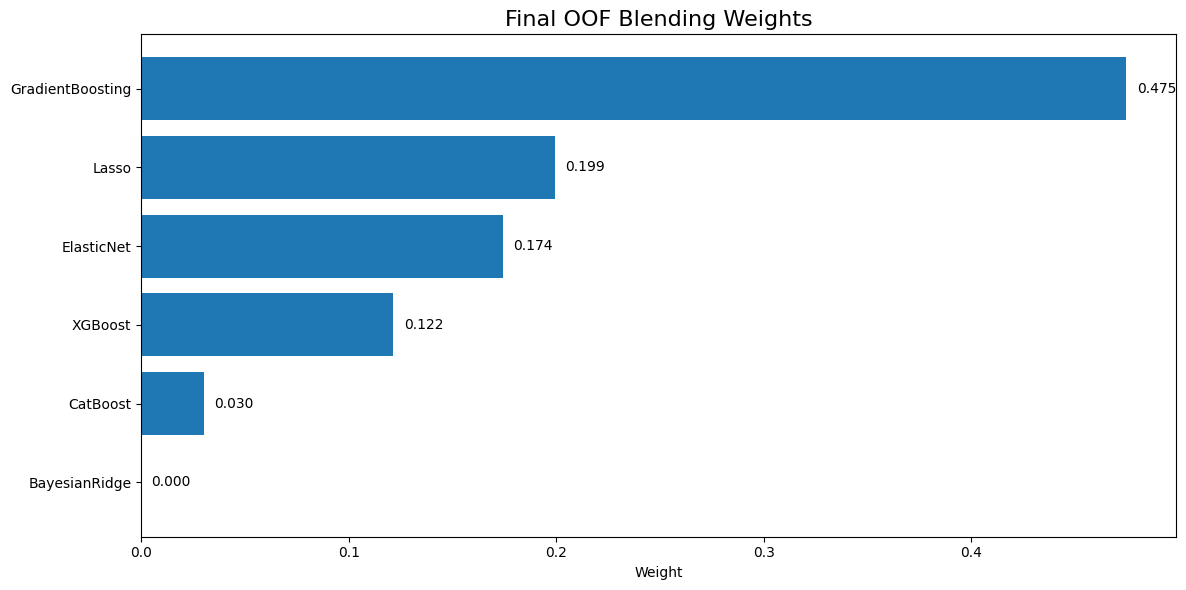

Saved: /kaggle/working/figures/15_predicted_saleprice_distribution.png


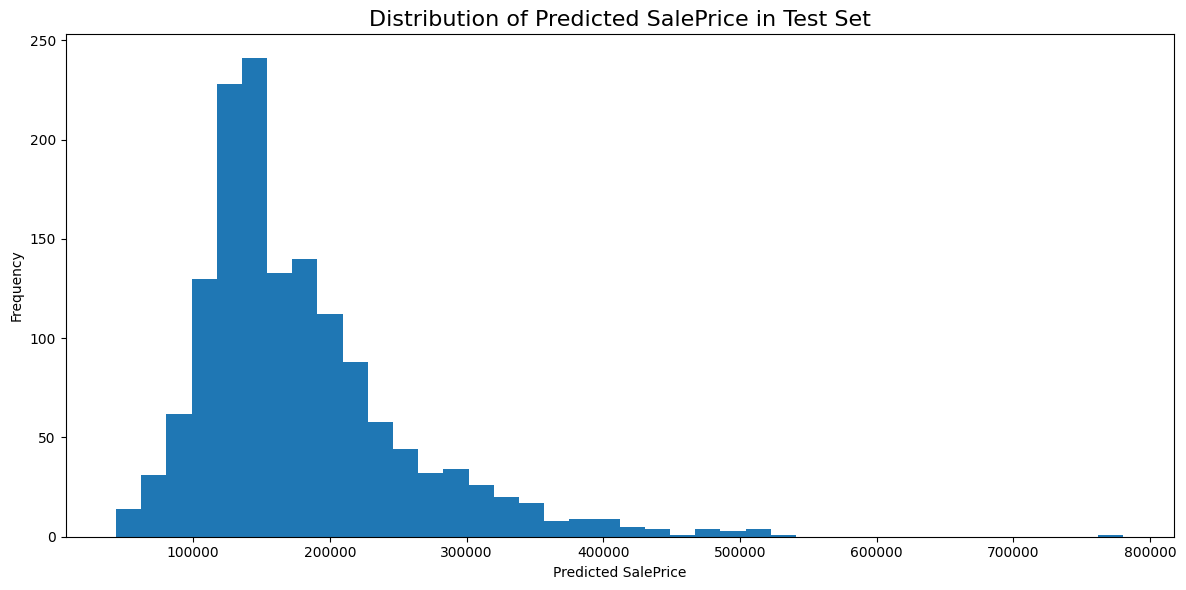

count      1459.000000
mean     178445.649131
std       77387.311007
min       43519.863434
25%      127746.538130
50%      157397.055796
75%      210191.263130
max      780551.779359
Name: SalePrice, dtype: float64

Saved: /kaggle/working/figures/16_train_vs_predicted_saleprice_distribution.png


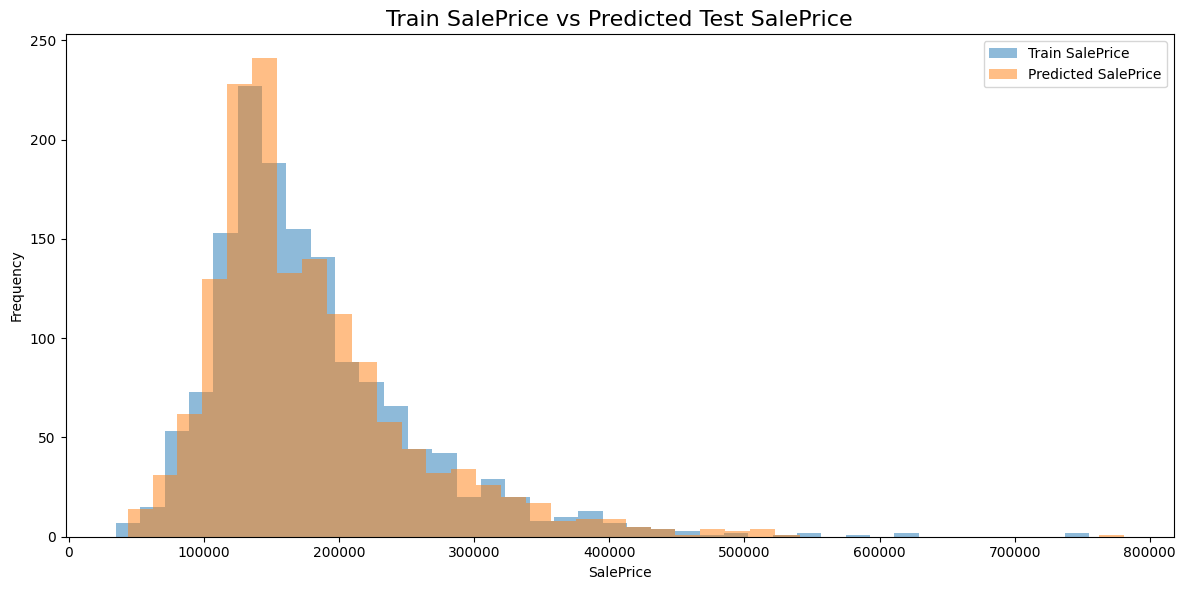

In [35]:
# PRESENTATION FIGURES 14-16 — Ensemble and Prediction Distribution

ensemble_weights_df = pd.DataFrame({
    "Model": selected_model_names,
    "Weight": best_weights
}).sort_values("Weight", ascending=True)

display(ensemble_weights_df.sort_values("Weight", ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(ensemble_weights_df["Model"], ensemble_weights_df["Weight"])
ax.set_title("Final OOF Blending Weights", fontsize=16)
ax.set_xlabel("Weight")

for i, v in enumerate(ensemble_weights_df["Weight"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)

save_fig("14_final_ensemble_weights.png")
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(submission["SalePrice"], bins=40)
ax.set_title("Distribution of Predicted SalePrice in Test Set", fontsize=16)
ax.set_xlabel("Predicted SalePrice")
ax.set_ylabel("Frequency")

save_fig("15_predicted_saleprice_distribution.png")
plt.show()

display(submission["SalePrice"].describe())


fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(train["SalePrice"], bins=40, alpha=0.5, label="Train SalePrice")
ax.hist(submission["SalePrice"], bins=40, alpha=0.5, label="Predicted SalePrice")

ax.set_title("Train SalePrice vs Predicted Test SalePrice", fontsize=16)
ax.set_xlabel("SalePrice")
ax.set_ylabel("Frequency")
ax.legend()

save_fig("16_train_vs_predicted_saleprice_distribution.png")
plt.show()

In [36]:
#cell17
print("Submission columns:", submission.columns.tolist())
print("Số dòng submission:", len(submission))
print("Số dòng test:", len(test))

assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test)
assert submission["SalePrice"].isnull().sum() == 0
assert (submission["SalePrice"] >= 0).all()

display(submission.head(10))
display(submission.describe())

print("Final file ready for Kaggle submission:")
print("/kaggle/working/submission.csv")

Submission columns: ['Id', 'SalePrice']
Số dòng submission: 1459
Số dòng test: 1459


,Id,SalePrice
0,1461,122576.365556
1,1462,157582.266545
2,1463,183910.265596
3,1464,197472.088919
4,1465,190021.233331
5,1466,173738.582807
6,1467,174884.667876
7,1468,165375.463067
8,1469,187285.835964
9,1470,123698.206080


,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,178445.649131
std,421.321334,77387.311007
min,1461.000000,43519.863434
25%,1825.500000,127746.538130
50%,2190.000000,157397.055796
75%,2554.500000,210191.263130
max,2919.000000,780551.779359


Final file ready for Kaggle submission:
/kaggle/working/submission.csv


Best single model by CV: GradientBoosting


,Feature,Importance
66,OverallQual_GrLivArea,0.127532
53,TotalSF,0.086565
4,OverallQual,0.067227
67,OverallCond_TotalSF,0.060568
25,GrLivArea,0.048595
56,HouseAge,0.042910
65,OverallQual_TotalSF,0.040882
54,TotalBath,0.037023
11,BsmtQual,0.035981
6,YearBuilt,0.035736


Saved: /kaggle/working/figures/17_feature_importance.png


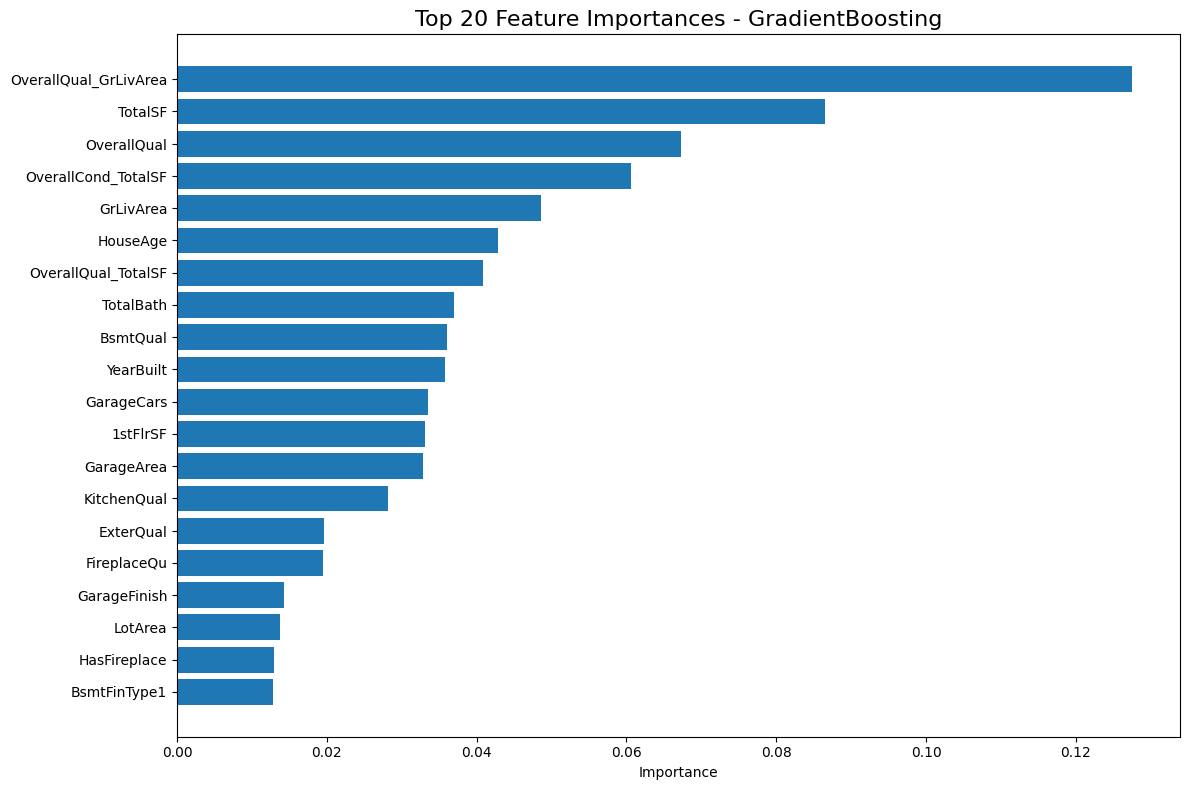

,Metric,Value
0,Public score,0.12643
1,Rank,756
2,Total teams,5126
3,Top percentage,14.75%


Saved: /kaggle/working/figures/18_kaggle_result_summary.png


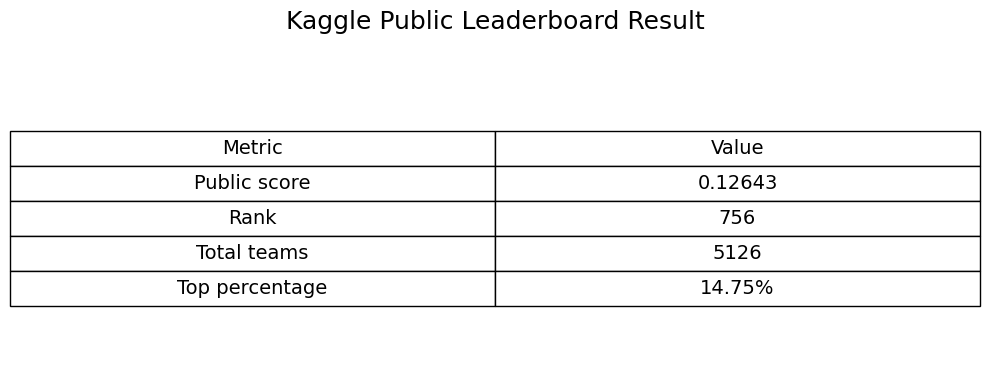

In [37]:
# PRESENTATION FIGURES 17-18 — Feature Importance and Kaggle Result

best_model_name = cv_results_df.iloc[0]["model"]
print("Best single model by CV:", best_model_name)

best_model = clone(models[best_model_name])
best_model.fit(X, y)

if isinstance(best_model, Pipeline):
    estimator = best_model.named_steps["model"]
else:
    estimator = best_model

feature_names = X.columns

if hasattr(estimator, "feature_importances_"):
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": estimator.feature_importances_
    }).sort_values("Importance", ascending=False)
    
    display(fi.head(25))
    
    plot_df = fi.head(20).sort_values("Importance")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(plot_df["Feature"], plot_df["Importance"])
    ax.set_title(f"Top 20 Feature Importances - {best_model_name}", fontsize=16)
    ax.set_xlabel("Importance")
    
    save_fig("17_feature_importance.png")
    plt.show()

elif hasattr(estimator, "coef_"):
    fi = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": estimator.coef_
    })
    fi["AbsCoefficient"] = fi["Coefficient"].abs()
    fi = fi.sort_values("AbsCoefficient", ascending=False)
    
    display(fi.head(25))
    
    plot_df = fi.head(20).sort_values("AbsCoefficient")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(plot_df["Feature"], plot_df["AbsCoefficient"])
    ax.set_title(f"Top 20 Absolute Coefficients - {best_model_name}", fontsize=16)
    ax.set_xlabel("Absolute coefficient")
    
    save_fig("17_feature_coefficients.png")
    plt.show()

else:
    print("This model does not expose feature_importances_ or coef_.")


kaggle_result = pd.DataFrame({
    "Metric": ["Public score", "Rank", "Total teams", "Top percentage"],
    "Value": ["0.12643", "756", "5126", f"{756/5126*100:.2f}%"]
})

display(kaggle_result)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=kaggle_result.values,
    colLabels=kaggle_result.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

ax.set_title("Kaggle Public Leaderboard Result", fontsize=18, pad=20)

save_fig("18_kaggle_result_summary.png")
plt.show()

In [38]:
# PRESENTATION FIGURES — List all saved images

figure_files = sorted([
    f for f in os.listdir(FIG_DIR)
    if f.endswith(".png")
])

print("Number of figures:", len(figure_files))

for f in figure_files:
    print(os.path.join(FIG_DIR, f))

Number of figures: 18
/kaggle/working/figures/01_dataset_overview.png
/kaggle/working/figures/02_data_quality_duplicate_id.png
/kaggle/working/figures/03_missing_values_train.png
/kaggle/working/figures/04_saleprice_distribution.png
/kaggle/working/figures/05_log_saleprice_distribution.png
/kaggle/working/figures/06_saleprice_by_overallqual_with_trend.png
/kaggle/working/figures/07_outlier_grlivarea_saleprice.png
/kaggle/working/figures/08_top_numeric_correlations.png
/kaggle/working/figures/09_neighborhood_median_saleprice.png
/kaggle/working/figures/10_modeling_pipeline.png
/kaggle/working/figures/11_feature_matrix_summary.png
/kaggle/working/figures/12_model_comparison_cv_rmse.png
/kaggle/working/figures/13_model_runtime_comparison.png
/kaggle/working/figures/14_final_ensemble_weights.png
/kaggle/working/figures/15_predicted_saleprice_distribution.png
/kaggle/working/figures/16_train_vs_predicted_saleprice_distribution.png
/kaggle/working/figures/17_feature_importance.png
/kaggle/wo